In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse

# Загрузка изображения

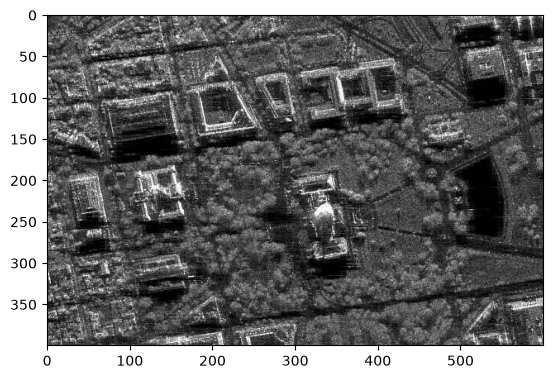

In [32]:
image = cv2.imread("sar_1_gray.jpg")
plt.imshow(image)

# Построение гистограммы

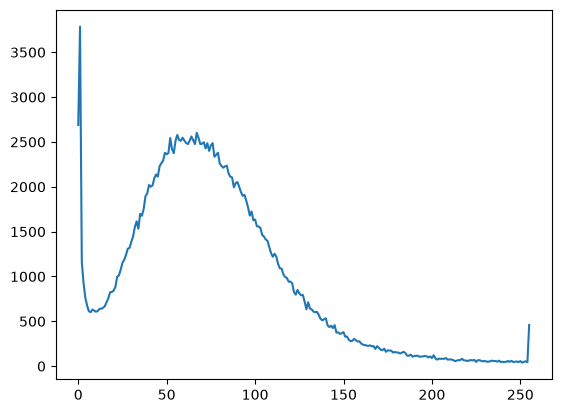

In [33]:
b = image[:,:,0]
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

plt.plot(b_hist)

# Алгоритм гамма коррекции

In [34]:
def gamma_correction(image, gamma):
    inv_gamma = 1 / gamma
    table = np.array([
        ((i / 255) ** inv_gamma) * 255
        for i in np.arange(0, 256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

## Гамма коррекция >1

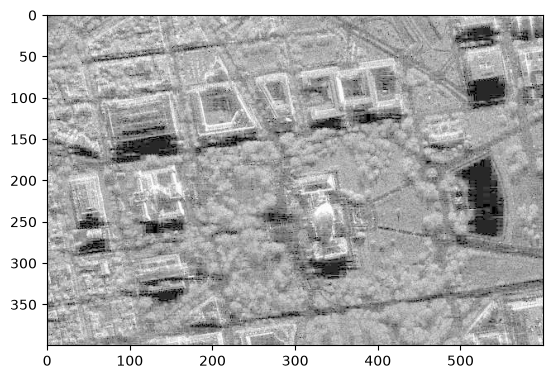

In [35]:
correction_1 = gamma_correction(image, 3)
plt.imshow(correction_1)

## Гамма коррекция <1

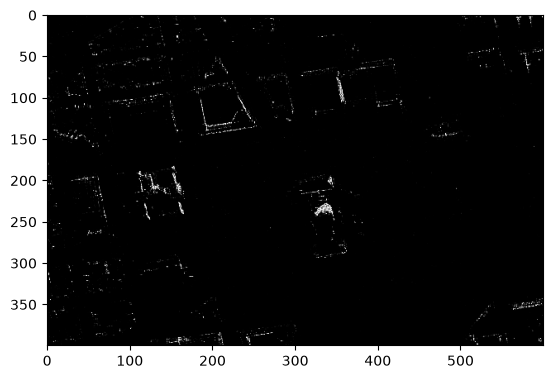

In [36]:
correction_2 = gamma_correction(image, 0.1)
plt.imshow(correction_2)

# SSIM, MSE

In [37]:
ssim_correction_1 = ssim(image, correction_1, channel_axis=2)
mse_correction_1 = mse(image, correction_1)

ssim_correction_2 = ssim(image, correction_2, channel_axis=2)
mse_correction_2 = mse(image, correction_2)

print("MSE correction_1: ", mse_correction_1)
print("SSIM correction_1: ", ssim_correction_1)

print("MSE correction_2: ", mse_correction_2)
print("SSIM correction_2: ", ssim_correction_2)

MSE correction_1:  7637.051045833334
SSIM correction_1:  0.6542966529630305
MSE correction_2:  6900.058620833333
SSIM correction_2:  0.029825955116113703


# Алгоритм статистической цветокоррекции на основе статистики eq_gray

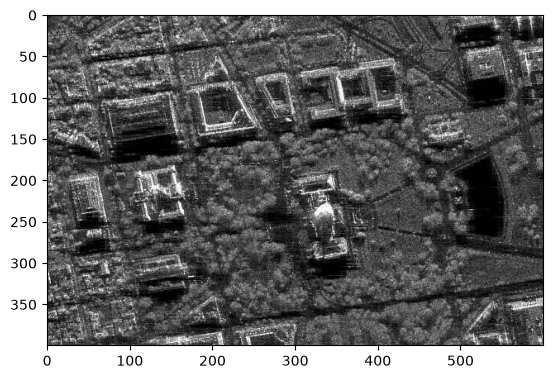

In [38]:
def color_correction_eq_gray(image):
    image = image.astype(np.float32)
    mean_b, mean_g, mean_r = np.mean(image, axis=(0, 1))
    gray_avg = (mean_b + mean_g + mean_r) / 3.0
    kb = gray_avg / mean_b
    kg = gray_avg / mean_g
    kr = gray_avg / mean_r
    image[:, :, 0] *= kb
    image[:, :, 1] *= kg
    image[:, :, 2] *= kr
    corrected = np.clip(image, 0, 255).astype(np.uint8)
    return corrected

img2 = color_correction_eq_gray(image)

plt.imshow(img2)

# Пороговая фильтрация

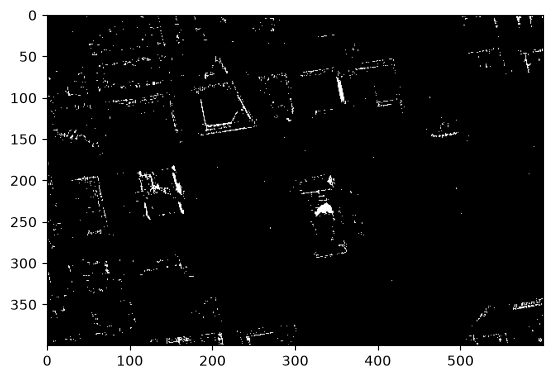

In [39]:
_, th_bin     = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)
plt.imshow(th_bin)
plt.show()

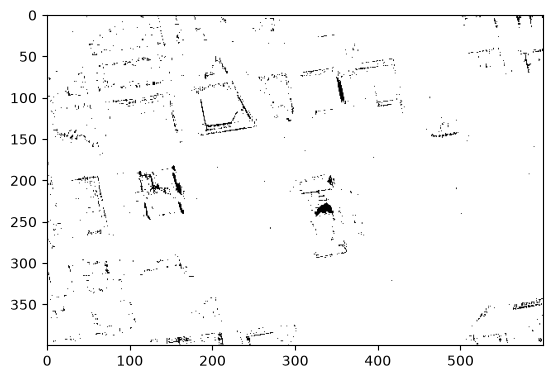

In [40]:
_, th_bin_inv = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY_INV)
plt.imshow(th_bin_inv)
plt.show()